# Methoden en Technieken 2025-2026 -- Blok 3 - Datapunt Opdracht 3B

## Opdracht

### Leer uitkomsten

In deze opdracht worden de volgende leeruitkomsten getoetst, relevante termen zijn **dik** gedrukt:
- A2: Je stelt voor een AI-oplossing juridische, ethische, organisatorische, **functionele en technische requirements** op.
- B2: Je **stelt op basis van requirements** en data **een geschikte architectuur voor een AI-oplossing op en selecteert daarvoor passende AI-technieken gebruik makend van bijvoorbeeld** **machine learning**, **deep learning**, kennisrepresentatie, computer vision en natural language processing.
- B3: Je **ontwikkelt een nieuw** of voorgetraind **AI-model volgens een iteratief en systematisch proces**.
- C2: **Je evalueert en beoordeelt de kwaliteit van een AI-model aan de hand van kwaliteitscriteria die in het vakgebied erkend worden** zoals robustness, **performance**, scalability, explainability, **model complexity** en resource demand.
(Leeruitkomst B1 is voor deze opdracht niet van toepassing.)

![](https://gymnasium.farama.org/_images/acrobot.gif)

## Uitleg

Het doel van deze opdracht is om een reinforcement learning model te maken dat het spel AcroBot speelt. Hier wil je een dubbele pendulum zo duwen dat het zo snel mogelijk een bepaalde hoogte bereikt.

Voor meer informatie over acties, belongingen, etc, zie [https://gymnasium.farama.org/environments/classic_control/acrobot/](https://gymnasium.farama.org/environments/classic_control/acrobot/).

- Stel een korte lijst van *requirements* op en verantwoord deze
- Kies een model en verantwoord je keuze
- Indien nodig, voer enkele (max 2) iteraties een verbeteringen uit, verantwoord je keuzes
- Evalueer je model (indien je .gif bestanden aanmaakt van gespeelde spellen, zoals in de code in de lessen, lever deze .gif bestanden ook in samen met dit notebook)
- Houd je antwoorden kort en bondig



De volgende code laad deze *environment* in.

## IMports

In [14]:
import gymnasium
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
import copy
import time
from sb3_contrib import QRDQN
from torchinfo import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

env = gymnasium.make("Acrobot-v1", render_mode="rgb_array_list")

Using device: cuda


## Omgeving

Het doel van deze opdracht is om een modelvrije reinforcement learning-oplossing te ontwikkelen voor de Acrobot-omgeving. In deze omgeving bestuurt een agent een tweedelige slinger, waarbij alleen het gewricht tussen de twee schakels actief wordt aangestuurd. Het doel is om door middel van het toepassen van koppel (torque) het vrije uiteinde van de slinger boven een bepaalde hoogte te krijgen, in zo min mogelijk stappen.

De taak is episodisch en vereist dat de agent leert om momentum op te bouwen via gecoördineerde acties. De omgeving is gebaseerd op werk van :contentReference[oaicite:0]{index=0} en wordt beschreven in het boek :contentReference[oaicite:1]{index=1}.

### Belangrijke eigenschappen van de omgeving

- Continue toestandsruimte (hoeken gerepresenteerd als sinus en cosinus, plus hoeksnelheden)
- Discrete actieruimte met drie mogelijke koppelwaarden: −1, 0 en +1
- Onderliggend systeem is continu en niet-lineair, ondanks de discrete acties
- Beloningsstructuur: −1 per stap tot het doel wordt bereikt, 0 bij terminatie (minimaliseren van tijd)
- Episodes duren maximaal 500 stappen, dus een lange horizon
- Volledig observeerbare toestand, er is geen geheugen nodig
- Dynamica is onbekend en moet via interactie geleerd worden (modelvrij)
- Beginstatus is dicht bij rust, waardoor het opbouwen van momentum essentieel is

## Functionele en technische requirements

1. Het systeem moet in staat zijn om stabiel te leren met functiebenadering (bijv. neurale netwerken), aangezien reinforcement learning methoden gevoelig zijn voor instabiliteit bij lange episodes.  
2. Het systeem moet effectief kunnen exploreren, omdat de beloningsstructuur vertraagd is en succes pas aan het einde van een episode wordt waargenomen.  
3. Het model moet geschikt zijn voor continue, niet-lineaire dynamica, aangezien het onderliggende systeem fysica-gebaseerd en continu is.  
4. De methode moet model-free zijn, omdat de overgangsdynamica van de omgeving niet expliciet beschikbaar is.  
5. Het systeem moet efficiënt omgaan met verzamelde ervaring, zodat training binnen redelijke tijd mogelijk blijft.  
6. Het model moet robuust zijn voor hyperparameterkeuzes, aangezien gevoeligheid kan leiden tot instabiele of inconsistente prestaties.  
7. Het systeem moet schaalbaar zijn naar langere episodes (tot 500 stappen) zonder dat prestaties sterk verslechteren.  
8. Het model moet werken met een discrete maar controle-georiënteerde actieruimte, waarbij acties een benadering vormen van continue controle.  
9. Het systeem mag geen afhankelijkheid hebben van geheugen of sequentiële modellering, aangezien de volledige toestand observeerbaar is.  
10. De modelcomplexiteit moet beperkt blijven en afgestemd zijn op de lage dimensie van de toestandsruimte, om overfitting en onnodige rekentijd te voorkomen.  
11. Er moet een relevante baseline worden gedefinieerd (bijv. een random agent of eenvoudige heuristische policy) die dient als ondergrens voor prestaties.  
12. De gekozen methode moet aantoonbaar beter presteren dan de baseline, gemeten in termen van gemiddelde episodische return en/of het aantal stappen tot het behalen van het doel.  

### Toelichting op trade-offs

Deze requirements volgen direct uit de eigenschappen van de Acrobot-omgeving: continue dynamica, vertraagde beloningen en lange episodes maken stabiliteit en exploratie de belangrijkste uitdagingen. Tegelijkertijd ontstaat er een spanningsveld tussen stabiliteit en efficiëntie, aangezien on-policy methoden doorgaans stabieler zijn en off-policy methoden efficiënter omgaan met data. In deze opdracht wordt gekozen voor methoden die een balans bieden tussen beide. Daarnaast bestaat er een trade-off tussen modelcomplexiteit en efficiëntie, waarbij bewust wordt gekozen voor een compact model passend bij de lage-dimensionale toestandsruimte. Moderne methoden zoals Soft Actor-Critic (off-policy maximum entropy reinforcement learning) laten zien dat het mogelijk is om deze trade-offs effectief te balanceren.

## Baseline

Describe baseline plan here

## Modelkeuze

### Gemaakte keuzes

**Uitdagingen op basis van environment**

De Acrobot-omgeving is een model free controleprobleem met continue, niet-lineaire dynamiek en een kleine discrete actieruimte. Hoewel de acties discreet zijn, uit dit zich in een continue controle. In combinatie met lange episodes (tot 500 stappen) en een reward van −1 per stap ontstaat een dichte maar zwak informatieve rewardstructuur. De belangerijskte uitdagingen voor het gekozen model om op te lossen.

- Stabiliteit
- Exploration
- Robustness voor leren over een lange horizon

**Eerste selectie: modelvrije reinforcement learning**

Om een keuze te maken aan de hand van de vele mogelijkheden heb ik de spinning up flow chart van OpenAI gebruikt die om een snelle overview te krijgen van de opties. De eerste keuze die gemaakt is is tussen de model-based en model free methoden. Model free is gekozen omdat de dynamics van de omgeving niet expliciet beschikbaar zijn en doormiddel van interactie met de environment geleerd moeten worden. 


<img src="./model_selection_flow_chart.png" alt="model choice flow" width="500"/>

**Tweedeling: policy optimization vs Q-learning**

Binnen modelvrije methoden ontstaat een keuze tussen:

- Policy optimization / actor–critic (DDPG, TD3, SAC)  
- Q-learning (DQN en varianten)  

Actor–critic methoden hebben als voordeel dat ze sterk zijn in continue controle en hhet bieden van stabielere updates *[1](H3, pg 4: "The weights of these target networks are then updated by having them slowly track the learned networks... This means that the target values are constrained to change slowly, greatly improving the stability of learning.")*. Het nadeel is dat ze actor-critic methoden gelijktijdig een policy leren en een value function dit kan er toe leiden datde oplossing complexer is en meer hyperparameters heeft. Omdat de acrobot omgeving een kleine discrete ruimte heeft gaat en gaat de voorkeur uit voor value-based methods. De eerste bekeken modellen zijn daarom de Q-learning based methods met als alternatief de actor-critics die mogelijk voordeel bieden als er veelr uis is door de randomness in de environment.

**Verfijning via RL-Picker en literatuur**

Om de verdere keuze te maken op basis van de selectie van de flow chart is er gebruik gemaakt van de RL-Picker tool op basis van de paper van [2] de paper is niet zo vaak geciteerd en daarom is het gebruikt als een cross validation met de selectie van de flow chart en om verdere selectie te ondersteunen en een sterk overzicht te hebben van modellen en de bijhorende papers. De volgende settings zijn gebruikt op basis van het probleem beschreven boven aan de notebook en de requirements. 

De setting die beiden kanten op kan gaan is de "rewards" sectie met de opties non-deceptive and quite dense, of sparse, deceptive or unclear in advance. Ondanks dat succes pas aan het einde zichtbaar is is er een dense maar weak signaal omdat er constant feedback is op de status van het doel. De resultaten van de tool laten het volgende zien:

<img src="./rl_picker_selection.png" alt="model choice flow" width="500"/>

Bij de flow chart waren de actor-critics voor nu achterwegen gelaten en in de picker hier is dit ook terug te zien, distributional methoden krijgen ook hier de voorkeur voor deze context vanwegen stabiliteit en verwachte betere representaties omdat ze variatie verminderen in value estimates voor een stabielere leer dynamiek *[3](H1: "The distributional Bellman operator preserves multimodality in value distributions, which we believe leads to more stable learning. Approximating the full distribution also mitigates the effects of learning from a nonstationary policy. As a whole we argue that this approach makes approximate reinforcement learning significantly better behaved)* , de actor-critics zijn zoals te zien als nog een valid alternatief. Van de 4 modellen uit de flow chart zijn er na het vergelijken nog 2 opties C51 en QR-DQN de andere twee modellen vallen af omdat ze Not distributional zijn en DQN bekend staat om instabiliteit en overestimation bias bij functiebenadering bekend staat *[4](Results on overoptimism, pg 5 :"Notice that the increases in value estimates for DQN [...] coincide with decreasing scores. [...] This indicates that the overestimations are harming the quality of the resulting policies... suggesting that the cause for these instabilities is in fact Q-learning’s overoptimism.")*. Dee paper en de tool beschrijven ook [5][6]"Distributional approaches are preferred instead because they may improve exploration generalization, training stability, and overall performance at the cost of training an additional density estimator"

De tooll geeft ook nog 2 andere opties die niet in de flow chart zijn GAN Q-learning en Bootstrapped DQN, deze zijn uitgesloten omdat GAN Q-learning meer risico heeft op instabiliteit en minder praktisch toepasbaar is. Bootstrapped DQN heeft als voordeel dat het beter instaat is goede resultaten te halen, maar hier staat tegen over dat het voor complexere exploration problemen is en meer rekentijd nodig heeft..

Met behulp van de flow chart en een extra check met de RL-picker tool en informatie van de paper blijven twee logische opties over:
De laatste keuze is nu tussen, de twee distributional reinforcement learning methodes lijken logische keuzes omdat ze  niet alleen de verwachte return leren, maar de volledige verdeling. Dit heeft de volgende effecten:(properly mention why the distributional solution makes sense since it can handel issues with noise door variance te verminderen in de value estimation in the environment without the extra coplexity of the actor-critic)

- stabielere updates  
- betere representaties van onzekerheid  

- Distributional DQN (also called c51)
- QR-DQN

**Vergelijking: C51 vs QR-DQN  

Beide methoden behoren tot distributional reinforcement learning en modelleren de volledige returnverdeling, wat helpt bij het verminderen van variantie en instabiliteit.

Het verschil zit in de representatie:

- **C51** gebruikt een vaste, discreet support  
  - vereist vooraf gekozen grenzen voor de return  
  - gevoelig voor verkeerde assumptions  

- **QR-DQN** leert direct de quantiles van de verdeling  
  - geen vooraf gedefinieerde support nodig  
  - flexibeler en beter aanpasbaar aan de omgeving  

In een omgeving zoals Acrobot, waar de returnverdeling niet eenvoudig vooraf te bepalen is, is dit een belangrijk voordeel. De paper van Dabney et al. *[6](Abstract: " Finally, we evaluate this new algorithm on the Atari 2600 games, observing that it significantly outperforms many of the recent improvements on DQN, including the related distributional algorithm C51.")* laat zien dat QR-DQN vaak beter presteert dan C51.

### Definitieve keuze  

Op basis van bovenstaande analyse wordt gekozen voor:

**Quantile Regression DQN (QR-DQN)**  

Deze methode biedt een sterke combinatie van:

- stabiliteit (door distributional learning)  
- flexibiliteit (geen vaste returngrenzen)  
- goede aansluiting bij discrete acties  

Hiermee vormt QR-DQN een logische keuze binnen de geïdentificeerde oplossingsruimte die op basis van staps gewijs model keuzes vergelijkene en uitsluiten logisch voort vloeit.

### Iteratiestrategie  

Hoewel QR-DQN als primaire methode wordt gekozen, blijven er twee logische vervolgstappen voor een tweede iteratie.

Indien tijdens training blijkt dat er als nog veel instabiliteit is of hoge variantie ondanks dat dedistrbutions hier bij zouden moeten helpen, is het misschien nodig om als tweede iteratie een ander model te keizen zoals een actor–critic methode zoals SAC, die stabiliteit nog verder kan verbeteren via een andere aanpak (entropy-regularisatie).  

Als het blijkt dat de prestaties goed en stabiel zijn  is een betere keuze voor een tweede iteratie hter verder optimaliseren van QR-DQN, met hyper param tuning of een architecture change aan de hand van de resultaten.

### Conclusie  

De modelkeuze volgt een systematische reductie van het oplossingsdomein: van modelvrije methoden naar Q-learning, vervolgens naar distributional varianten, en uiteindelijk naar QR-DQN als meest geschikte methode. Deze keuze sluit het beste aan bij de eigenschappen van de omgeving en de gestelde requirements, terwijl er ruimte blijft voor gerichte iteratie.

## QR-DQN setup and eval

### Hyperparams

asd

### Evaluation

ads

## QR-DQN (Quantile Regression DQN)

QR-DQN models the full distribution of returns using fixed quantile fractions, rather than just the mean Q-value. This gives the agent a richer understanding of uncertainty in value estimates, which can improve learning stability and exploration. The loss uses the quantile Huber loss to regress each quantile toward the target distribution.

**Key idea**: Instead of predicting $Q(s, a)$, the network predicts $N$ quantiles $\theta_i(s, a)$ for $i = 1, \ldots, N$, with fixed quantile midpoints $\tau_i = \frac{2i - 1}{2N}$.

## Training

In [ ]:
from stable_baselines3.common.callbacks import BaseCallback

class RewardLoggerCallback(BaseCallback):
    """Logs episode rewards during training."""
    def __init__(self):
        super().__init__()
        self.episode_rewards = []

    def _on_step(self):
        infos = self.locals.get("infos", [])
        for info in infos:
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])
        return True

policy_kwargs = dict(
    net_arch=[24, 24],
    n_quantiles=5
)

model = QRDQN(
    "MlpPolicy",
    "Acrobot-v1",
    policy_kwargs=policy_kwargs,
    learning_rate=1e-3,
    batch_size=64,
    gamma=0.99,
    target_update_interval=3000,
    buffer_size=50000,
    exploration_fraction=0.625,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.01,
    verbose=1,
)

total_params = sum(p.numel() for p in model.policy.parameters())
print(f"Total parameters: {total_params}")
print(model.policy)

In [ ]:
print(model.policy)

# Feature extractor (usually identity or flatten for MLP)
print("Features extractor:")
print(model.policy.features_extractor)

# Q-network (main network)
print("\nQ-network:")
print(model.policy)

# Target network
print("\nTarget Q-network:")
print(model.policy.quantile_net)

for name, param in model.policy.named_parameters():
    print(f"{name}: {param.shape} -> {param.numel()} params")

summary(model.policy, input_size=(1, 6))  # Acrobot has 6 state features


In [19]:
print("Training QR-DQN (sb3-contrib)...")
reward_callback = RewardLoggerCallback()
start_time = time.time()

model.learn(total_timesteps=200_000, log_interval=100, callback=reward_callback)
train_time = time.time() - start_time

model.save("qrdqn_acrobot")
qrdqn_rewards = reward_callback.episode_rewards
print(f"Training complete in {train_time:.1f}s, {len(qrdqn_rewards)} episodes")

Training QR-DQN (sb3-contrib)...
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 485      |
|    ep_rew_mean      | -485     |
|    exploration_rate | 0.616    |
| time/               |          |
|    episodes         | 100      |
|    fps              | 693      |
|    time_elapsed     | 69       |
|    total_timesteps  | 48474    |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.00807  |
|    n_updates        | 12093    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 465      |
|    ep_rew_mean      | -465     |
|    exploration_rate | 0.248    |
| time/               |          |
|    episodes         | 200      |
|    fps              | 642      |
|    time_elapsed     | 147      |
|    total_timesteps  | 95004    |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             

## Evaluation

Evaluate QR-DQN against a random baseline on 20 fresh episodes.

In [20]:
print("Evaluating on 20 fresh episodes...\n")

# QR-DQN evaluation
eval_env = gymnasium.make("Acrobot-v1")
qrdqn_returns = []
for _ in range(20):
    state, _ = eval_env.reset()
    total_reward = 0
    done = False
    while not done:
        action, _ = model.predict(state, deterministic=True)
        state, reward, terminated, truncated, _ = eval_env.step(action)
        total_reward += reward
        done = terminated or truncated
    qrdqn_returns.append(total_reward)
eval_env.close()
qrdqn_mean, qrdqn_std = np.mean(qrdqn_returns), np.std(qrdqn_returns)

# Random baseline
eval_env = gymnasium.make("Acrobot-v1")
rand_returns = []
for _ in range(20):
    state, _ = eval_env.reset()
    total_reward = 0
    done = False
    while not done:
        action = eval_env.action_space.sample()
        state, reward, terminated, truncated, _ = eval_env.step(action)
        total_reward += reward
        done = terminated or truncated
    rand_returns.append(total_reward)
eval_env.close()
rand_mean, rand_std = np.mean(rand_returns), np.std(rand_returns)

print(f"{'Model':<20} {'Mean Return':>12} {'Std':>8}")
print("-" * 44)
print(f"{'Random Baseline':<20} {rand_mean:>12.1f} {rand_std:>8.1f}")
print(f"{'QR-DQN':<20} {qrdqn_mean:>12.1f} {qrdqn_std:>8.1f}")
print(f"\nImprovement over baseline: {qrdqn_mean - rand_mean:+.1f} return")

Evaluating on 20 fresh episodes...

Model                 Mean Return      Std
--------------------------------------------
Random Baseline            -500.0      0.0
QR-DQN                     -461.9    114.5

Improvement over baseline: +38.1 return


Model: QR-DQN
Mean return: -112.6
Std: 90.1
traintime: 1384.1

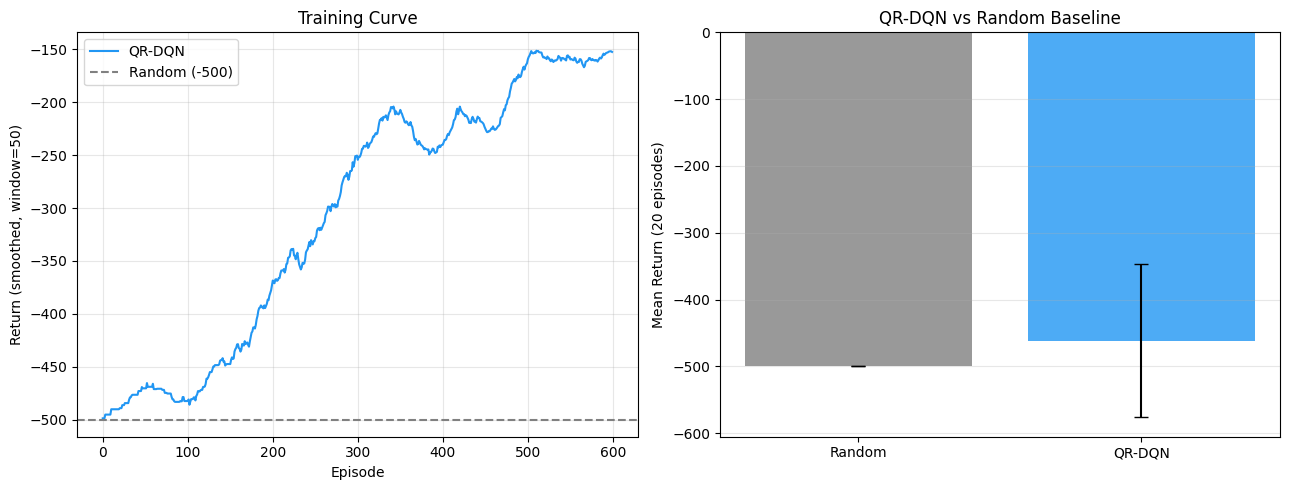

In [21]:
def smooth(rewards, window=50):
    return np.convolve(rewards, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Training curve
ax = axes[0]
ax.plot(smooth(qrdqn_rewards), label="QR-DQN", color="#2196F3")
ax.axhline(y=rand_mean, color='gray', linestyle='--', label=f"Random ({rand_mean:.0f})")
ax.set_xlabel("Episode")
ax.set_ylabel("Return (smoothed, window=50)")
ax.set_title("Training Curve")
ax.legend()
ax.grid(True, alpha=0.3)

# Final evaluation
ax = axes[1]
models = ["Random", "QR-DQN"]
means = [rand_mean, qrdqn_mean]
stds = [rand_std, qrdqn_std]
colors = ["gray", "#2196F3"]
ax.bar(models, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
ax.set_ylabel("Mean Return (20 episodes)")
ax.set_title("QR-DQN vs Random Baseline")
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("qrdqn_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()

- [1] https://arxiv.org/pdf/1509.02971
- [2] https://arxiv.org/abs/2407.20917
- [3] https://arxiv.org/abs/1707.06887
- [4] https://arxiv.org/abs/1509.06461
- [5] https://arxiv.org/abs/1712.02037
- [6] https://arxiv.org/abs/1602.04621